This notebook will cover an introduction into...
- Tiling
    - What is Tiling
    - Why do we do Tiling
    - How do we do Tiling
- Stickification
    - What is Stickification
    - Why do we do Stickification
    - How do we do Stickification

# 1. Tiling

## 1.1 What is Tiling

Tiling, otherwise known as "blocking", is a loop-level optimisation which involves the process of breaking down massive tensor operations into smaller, manageable blocks (tiles).

Tiling almost exclusilvey exists as a compiler level optimisation for AI Hardware (TPUs, NPUs, GPUs, etc...)

When we break down a large existing tensor into sub-tensors, we are creating "tiles", these tile are made by rearranging the elements of the existing large tensor along a specified dimensions. 

These dimensions are hardware defined, meaning they are sized specifically to match the register width or cache size of the target hardware.

#### Tiled Memory Format

A tiled format breaks down a shape into tiles (usually 1D or 2D). Tiles are laid out in memory in row-major layout. The elements within a tile are also laid out in major to minor order. This layout ensures that when a processor fetches a tile, the data is physically contiguous in memory.

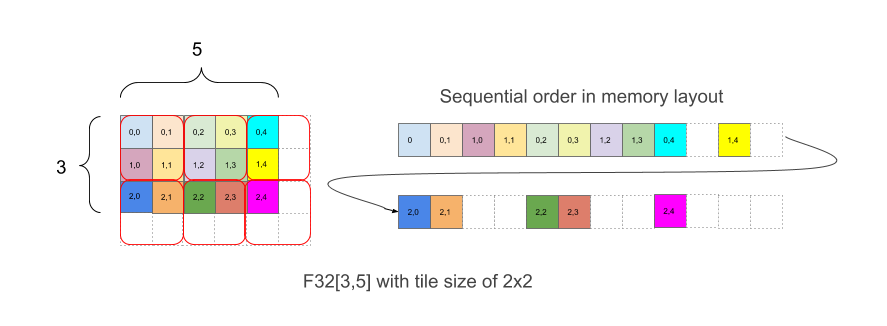

Source [4]

## 1.2 Why do we Tile

### Cache Misses
Tiling is applied to reduce non-optimal performance due to innefficient cache use, for example, imagine you write a matrix multiplication written program in C/C++, the operations are expressed through nested-loops. Most execution time of a scientific program, like this matrix multiplpication are spent on loops, if not optimised, this can lead to frequent cache misses.

A cache miss occurs when the processor tries to access data not currently on the cache and has to access the data from the DRAM. As DRAM is slower than the processor, the processor ends up sitting idle while waiting for data to be read, we call this being "memory bound".

"The CPU spends significant time waiting for data to be transferred, resulting in low utilization and, often, a bottleneck." This is what tiling tries to minimise.

The goal of tiling is to maximise data-reuse, once a tile is loaded into the cache, we want to perform as many mathmatical operations on it as possible. 

### Memory Hierachy
We all know that existing processors do have a cache - it is a small and fast memory located closer to a processor core and dedicated to minimizing an “expensive” access to DRAM. Note that cache is located between the processor and DRAM and keeps a copy of some data from main memory (DRAM). [1]

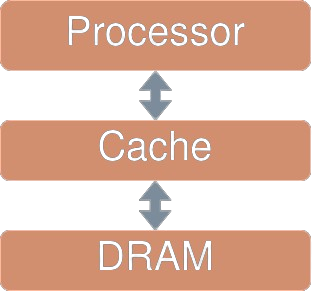

As a result, compilers use what are called "Loop-Nest Optimisations" to restructure the iteration space of these operations. Instead of moving through a million rows linearly, the compiler "tiles" the loop so it stays within a specific memory layout until that data is no longer needed.

#### What is an Iteration Space?
An 'Iteration Space' refers to the set of all possible executions of a loop or nested loops.

### Loops, it's all about loops
The general idea of this technique is to Block loops for cache reusechange the loop’s iteration space into smaller blocks in order to work with the memory hierarchy more efficiently, i.e. we can guarantee that the data used in the loop will fit the cache until it is reused.

So for example if you have a cache of 128 bytes, you would tile a tensor to fit this cache line. If you recalled back to secion 1 where I explained we tile along a specificed hardware dimensions, these dimensions define your cache or register size. 

### Spatial Locality
Tiling exploits two key principles:
- Temporal Locality: Re-using the same data piece multiple times in a short window.
- Spatial Locality: Accessing data elements that are physically stored near each other in memory.

By aligning tile sizes with hardware-defined dimensions, we guarantee that the data fits the cache perfectly, transforming a slow, memory-intensive task into a high-speed one.

## 1.3 How do we Tile?

### Example:

#### MatMul (Naive)
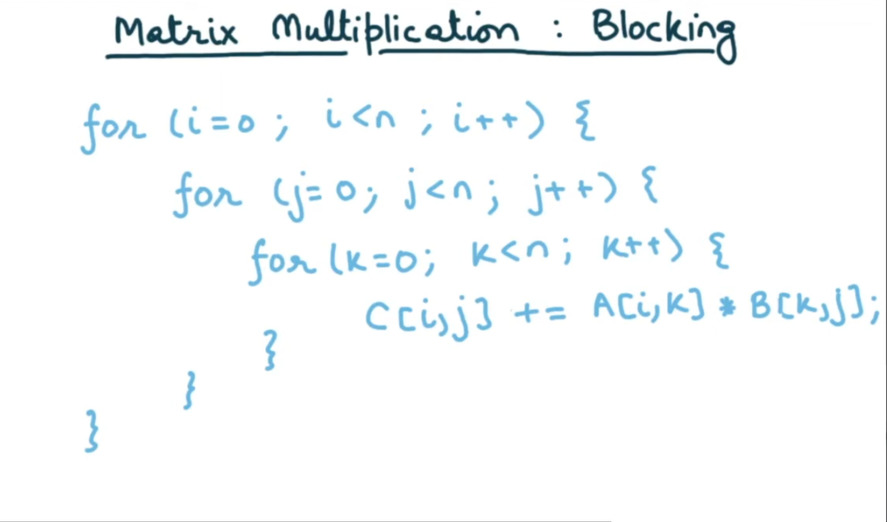

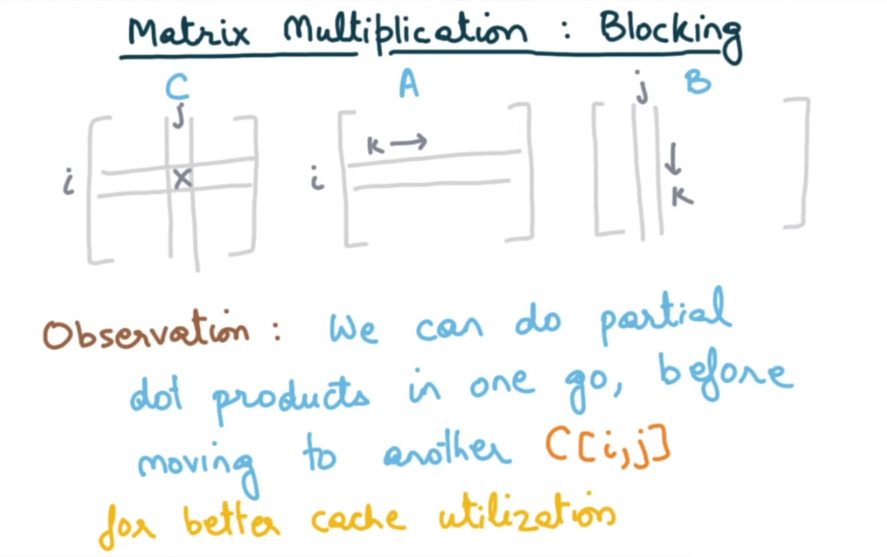

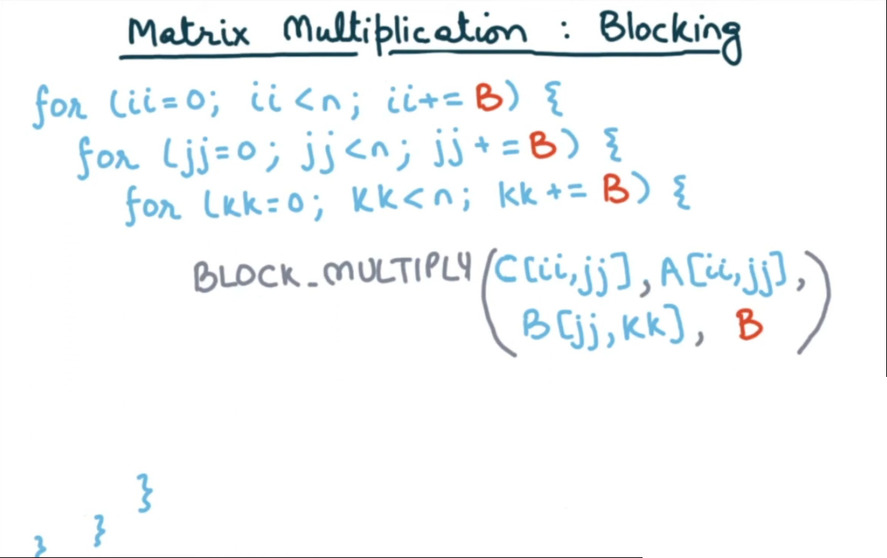

#### MatMul (Tiled)
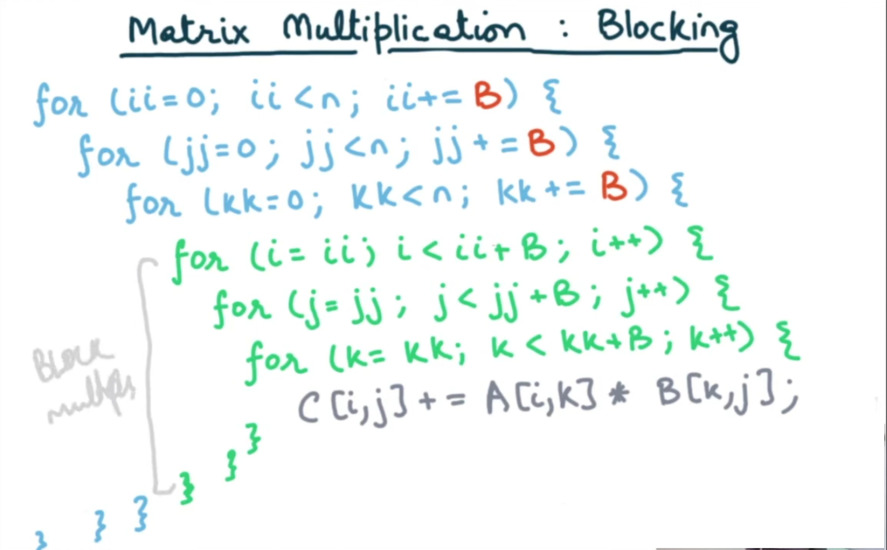


# 2. Stickification

### 2.1 What is Stickification

### 2.2 Why do we do Stickification?

### 2.3 How do we do Stickification

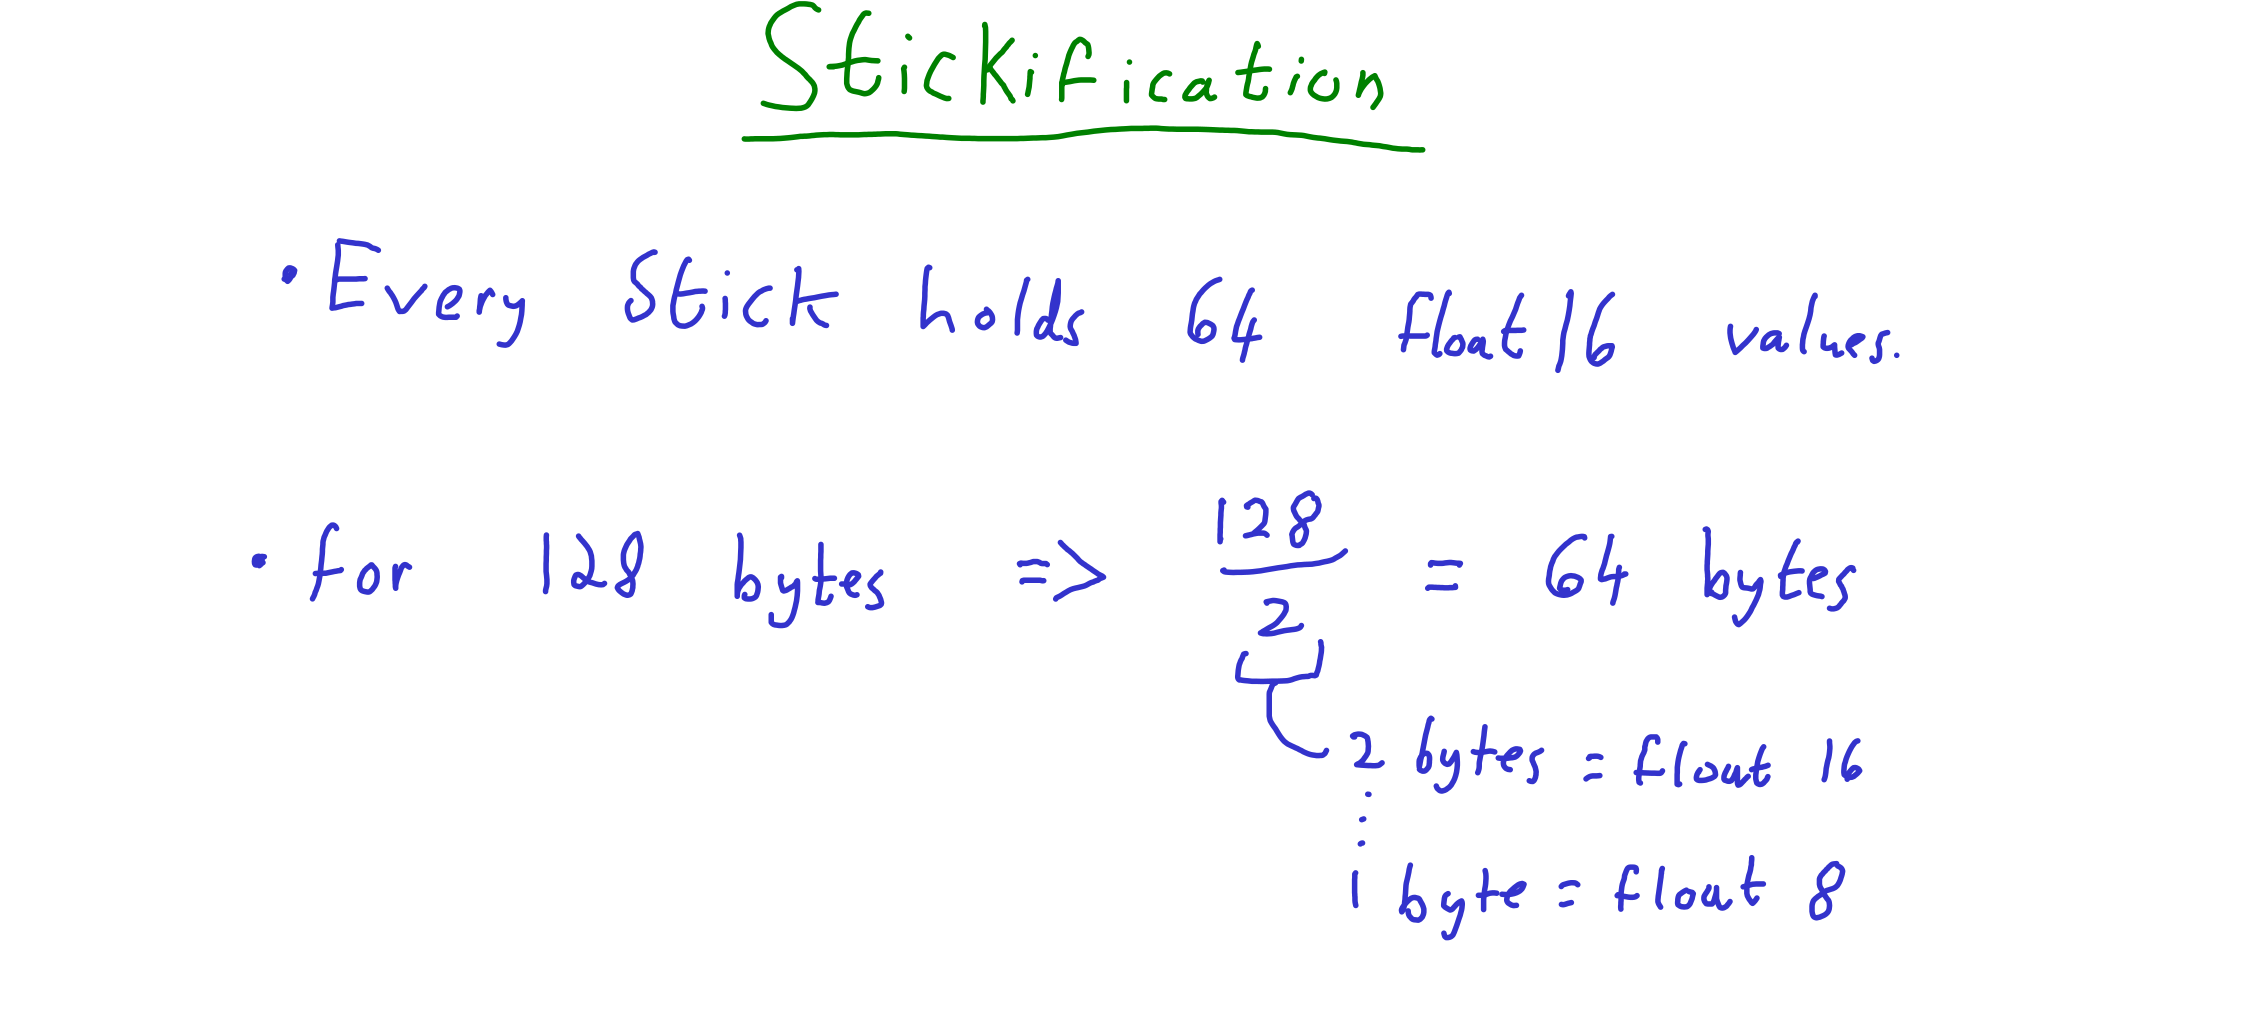


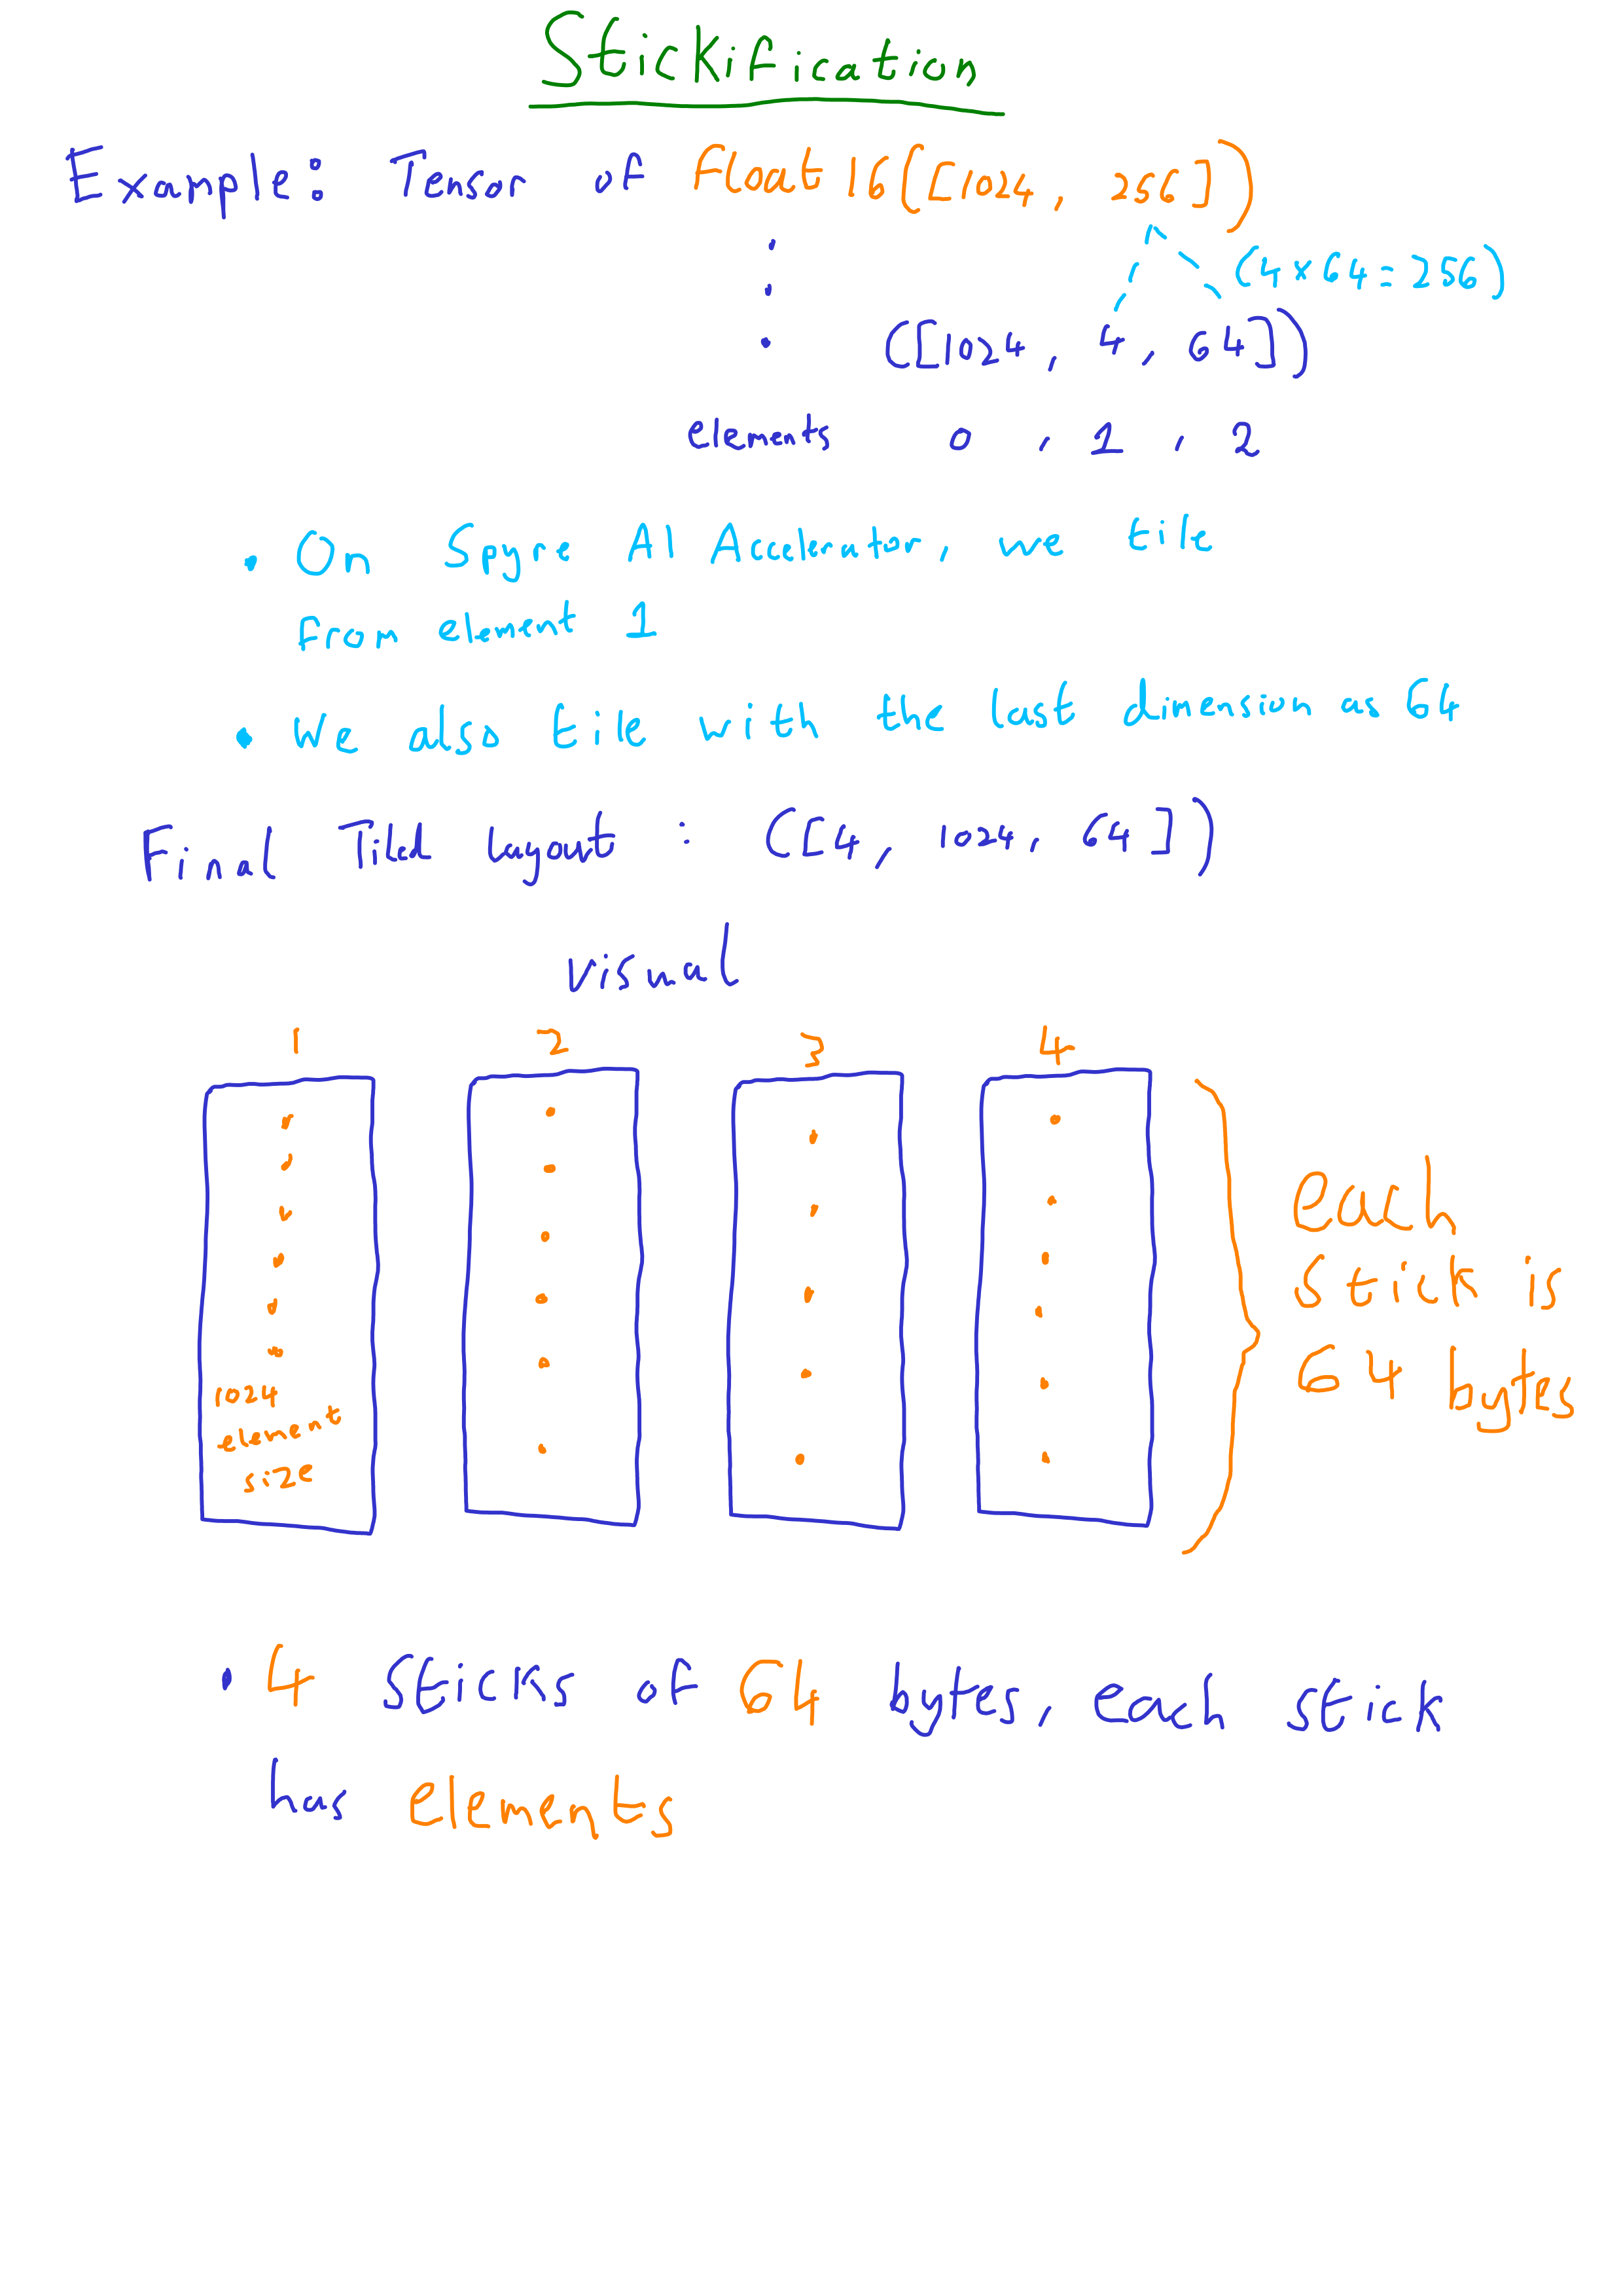

## Stickification Examples

Here is a quick example for 1D - 4D sizes:

```
The right-most dim is split (tiled) into the two dims where the right-most dim is 64:
[512]  -> [8, 64]

When there is more than 1 dim, the left-most dim is moved in between the right-most split dim:

[2, 512]        -> [8, 2, 64]
[2, 4, 512]     -> [4, 8, 2, 64]
[2, 4, 6, 512]  -> [4, 6, 8, 2, 64]

A mapping of the original dim that each dim comes from is stored to determine the original size:

Size			Device Size			dim_map
------------------------------------------------
(512)			(8, 64)				[0, 0]
(2, 512)		(8, 2, 64)			[1, 0, 1]
(2, 4, 512)		(4, 8, 2, 64)		[1, 2, 0, 2]
(2, 4, 6, 512)	(4, 6, 8, 2, 64)	[1, 2, 3, 0, 3]
```

## Stickication Examples

### 2D
- ([2, 512])
- [512] => [8, 64]
- New Tensor: ([2, 8, 64])
- Device Layout:
    -  left-most dim is moved in between the right-most split dim. Which is 2 here
    - ([8, 2, 64])
    - dim([1, 0, 1])

## Padding Example

Tensor of ([5, 100, 150])
- Last dim will always be 64
- 150 is not divisable by 64, we get a remainder of 3.
- 64 * 3 = 192. 
    - 192 - 150 = 42.
    - 42 is the padding needed for elements per row.
- 150 -> (3 sticks, 64 elements) 

##### Stickified layout:
**([5, 100, 150])** becomes **([5, 100, 3, 64])**
- [150] becomes [3, 64]
- Note: this layout is note a device layout for the device sizes

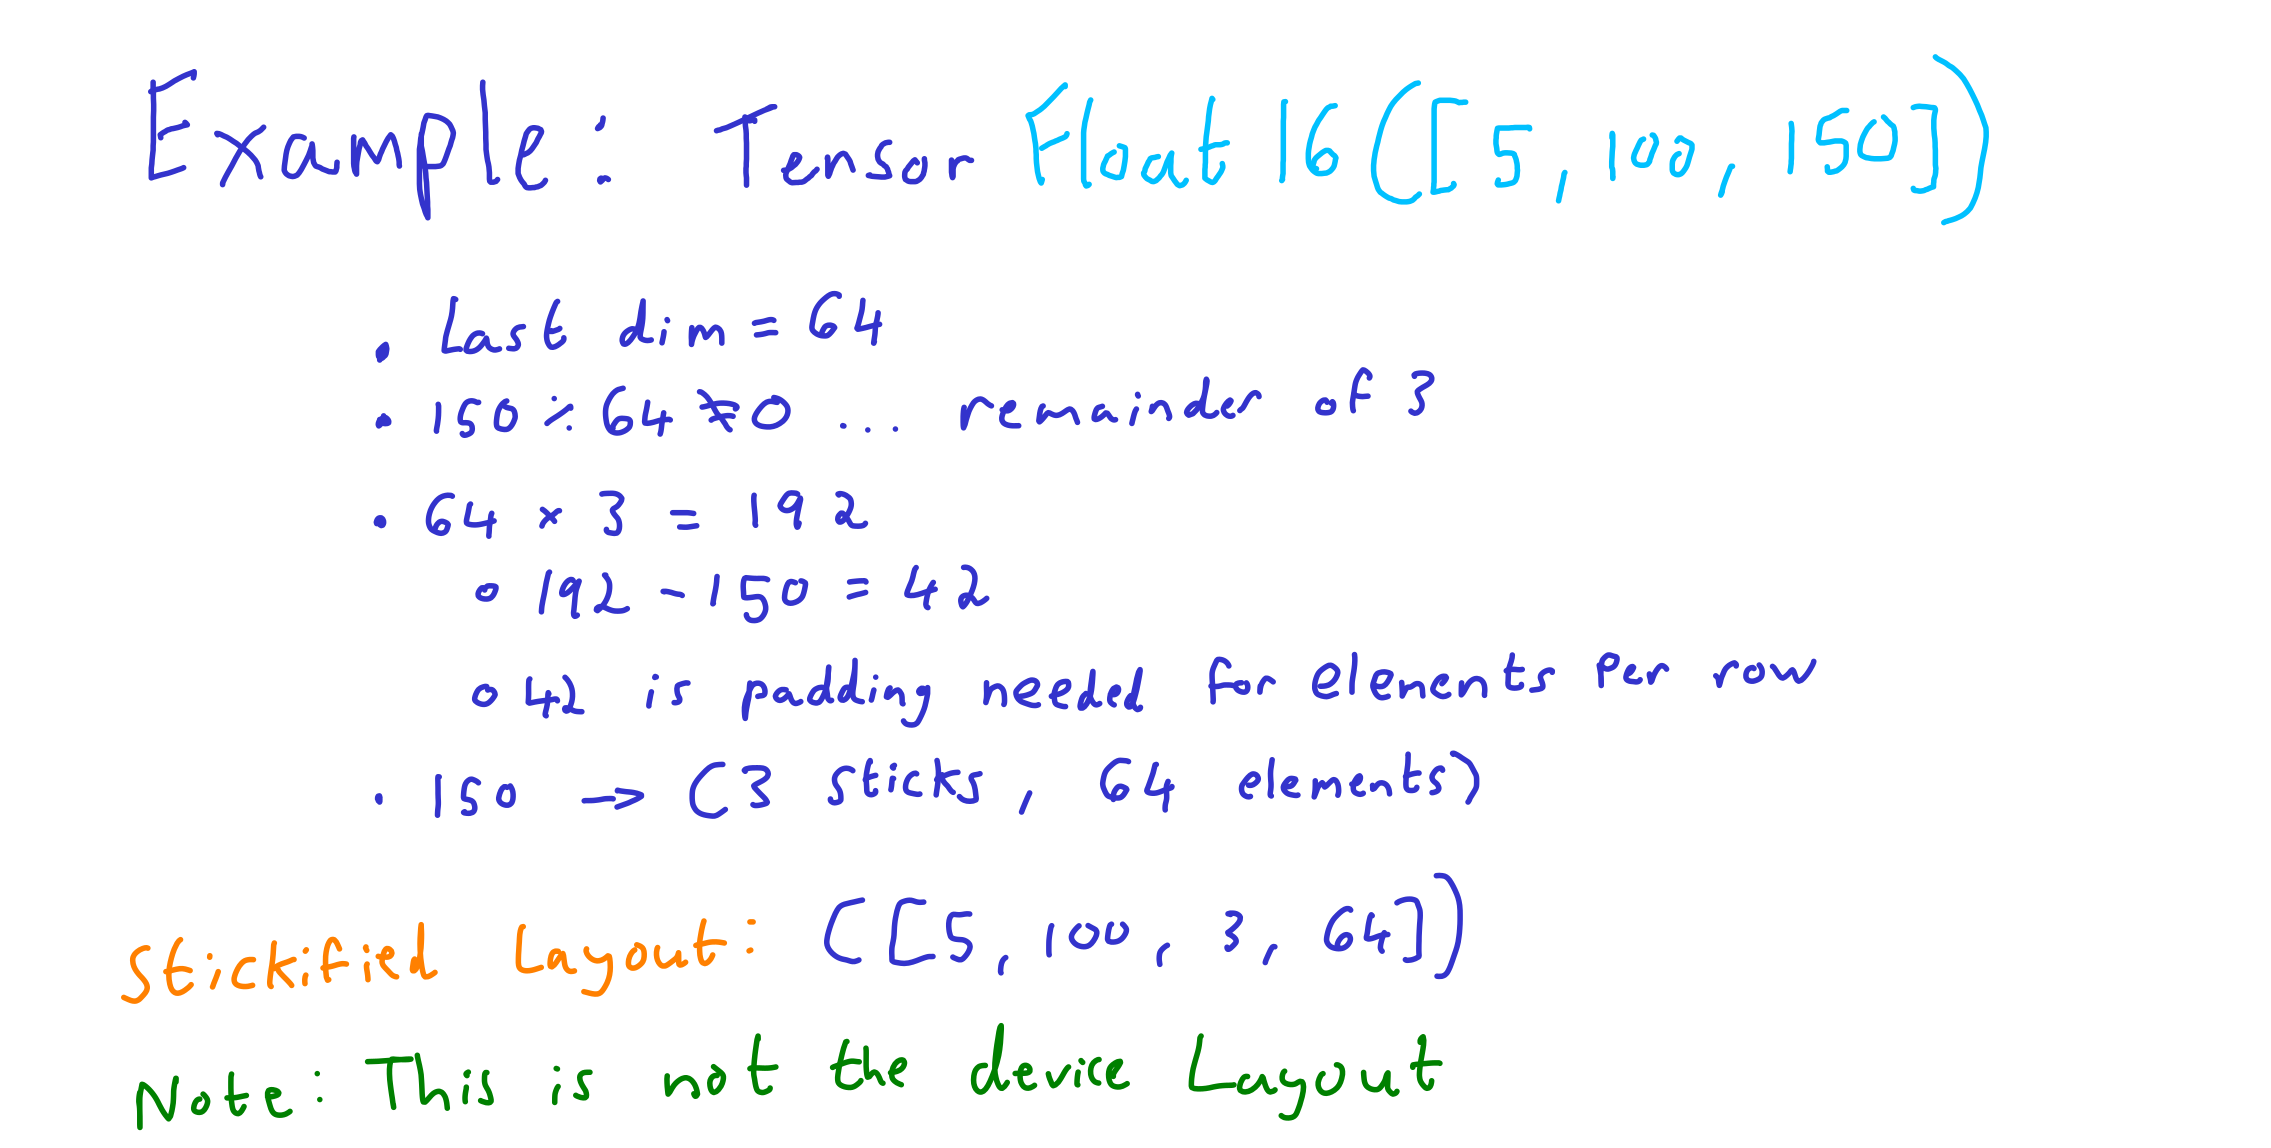

#### Device Layout:
- When there is more than 1 dim, the left-most dim is moved in between the right-most split dim:
- For example:
    - Let's say the sizes were 3-dimensional (*, *, 150). Then device sizes would be 4-dimensional (*, 3, *, 64).
- "the left-most dim is moved in between the right-most split dim"
    - 5 is the left-most here, it gets moved between the split [3, __, 64] 
- Result: [ 100,  3,  5,  64 ]

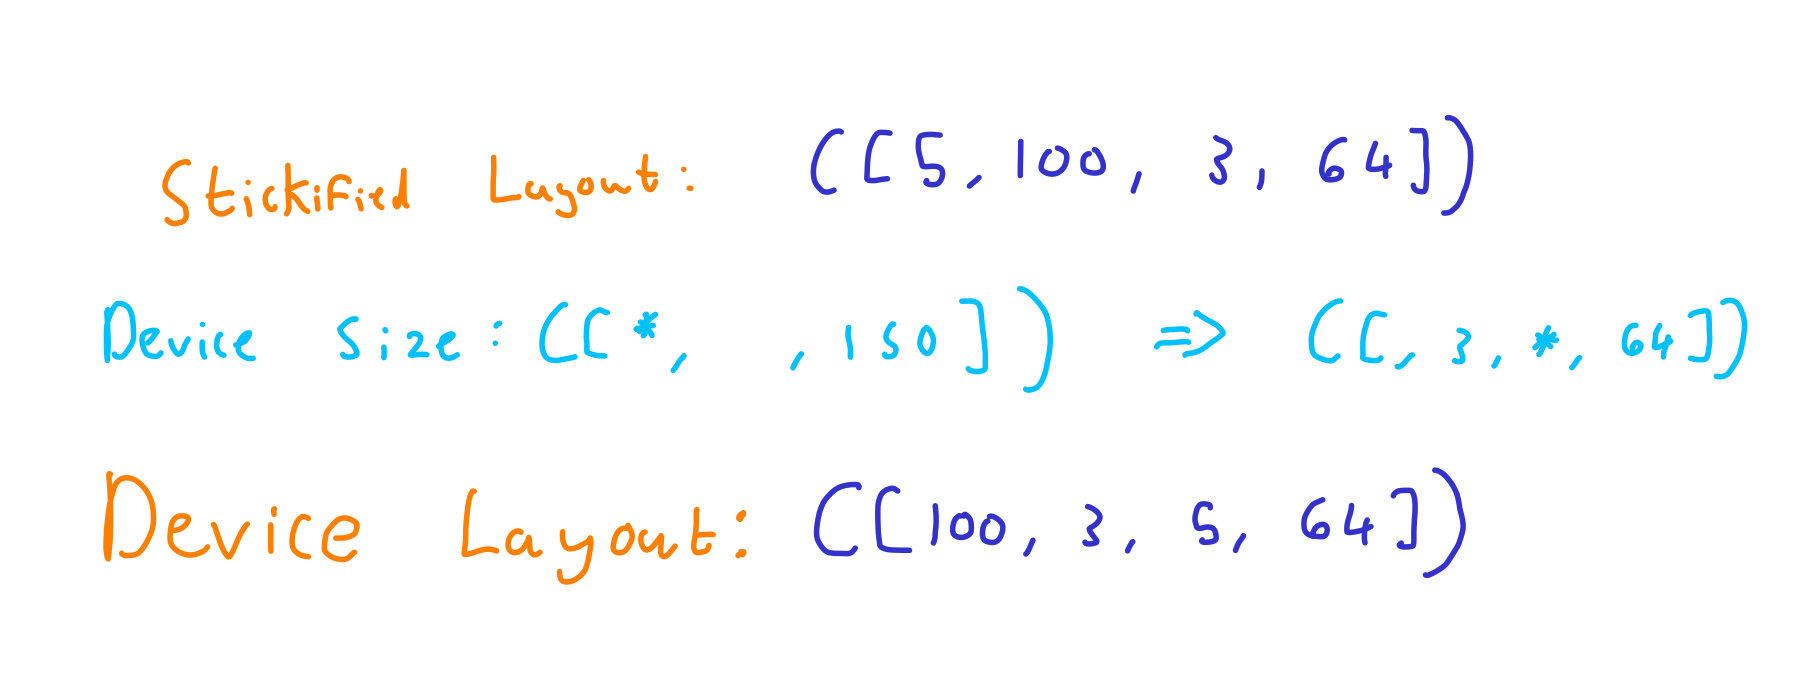

#### Summary:
Original Tensor [5 ,100, 150]
- right most element (150) gets split into 3 sticks of 64-bytes (with padding)
- device sizes 3 and 64 will always appear in the third-from-last and last device size (*, 3, *, 64)
- left most dim is moved in-between the right-most split dim. 5 is the left most dim here and is moved between [3, __, 64]
creating the final layout ([100, 3, 5, 64])

### Device Layout

want to describe why ([1024, 256]) became ([4,1024,64]) - i said in my diagram it was tiled from element 1 but thats wrong. It was reordered for device memory. need to fix that

the RFC method would tile the stickified tensor of [5,100,3,64] to [3,5,100,64]

# Resources
- [1] Intel: https://www.intel.com/content/www/us/en/developer/articles/technical/loop-optimizations-where-blocks-are-required.html
- [2] Cornell: https://www.cs.cornell.edu/courses/cs6120/2025fa/blog/tiling-fusion-search/
- [3] Vadim Karpusenko: https://www.youtube.com/watch?v=GkHrgxdVrdo
- [4] XLA: https://openxla.org/xla/tiled_layout